In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


DATA_PATH = '../data/raw/creditcard.csv'
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head(5))

Shape: 284807 rows, 31 columns



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:

df.info()


display(df[['Time', 'Amount', 'Class']].describe())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


In [ ]:
# 1. Missing Values
nulls = df.isnull().sum()
print("Missing values per column:\n", nulls[nulls > 0])

# 2. Duplicate Records
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records: {num_duplicates}")


if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Rows remaining after dropping duplicates: {df.shape[0]}")

Missing values per column:
 Series([], dtype: int64)

Number of duplicate records: 1081
Rows remaining after dropping duplicates: 283726


Legitimate (0): 283253 (99.833%)
Fraudulent (1): 473 (0.167%)


C:\Users\DE\AppData\Local\Temp\ipykernel_26096\1210296100.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=['#1f77b4', '#d62728'], ax=ax)
C:\Users\DE\AppData\Local\Temp\ipykernel_26096\1210296100.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Normal (0)', 'Fraud (1)'])


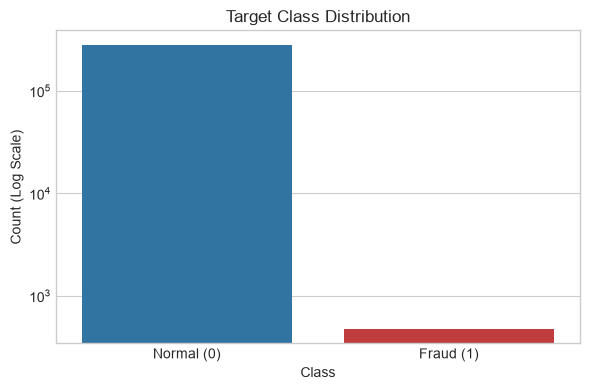

In [ ]:
counts = df['Class'].value_counts()
pcts = df['Class'].value_counts(normalize=True) * 100

print(f"Legitimate (0): {counts[0]} ({pcts[0]:.3f}%)")
print(f"Fraudulent (1): {counts[1]} ({pcts[1]:.3f}%)")


fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_yscale('log')
ax.set_xticklabels(['Normal (0)', 'Fraud (1)'])
ax.set_ylabel('Count (Log Scale)')
ax.set_title('Target Class Distribution')
plt.tight_layout()
plt.show()

C:\Users\DE\AppData\Local\Temp\ipykernel_26096\979341658.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, showfliers=False, palette=['#1f77b4', '#d62728'], ax=ax)
C:\Users\DE\AppData\Local\Temp\ipykernel_26096\979341658.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Normal', 'Fraud'])


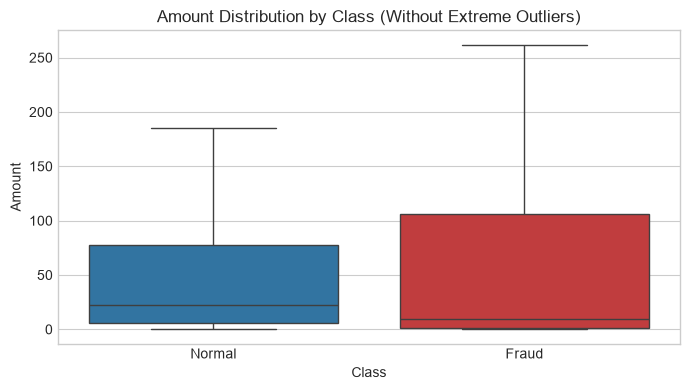

Upper bound for Amount: $185.38
Number of Fraud cases above upper bound: 87 out of 473


In [5]:
# box plot for 'Amount' by 'Class' without extreme outliers
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x='Class', y='Amount', data=df, showfliers=False, palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_xticklabels(['Normal', 'Fraud'])
ax.set_title('Amount Distribution by Class (Without Extreme Outliers)')
plt.tight_layout()
plt.show()

# IQR
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

fraud_outliers = df[(df['Amount'] > upper_bound) & (df['Class'] == 1)]
print(f"Upper bound for Amount: ${upper_bound:.2f}")
print(f"Number of Fraud cases above upper bound: {len(fraud_outliers)} out of {counts[1]}")

In [6]:
X = df.drop(columns=['Class'])
y = df['Class']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape} | Fraud ratio: {y_train.mean():.5f}")
print(f"X_test shape:  {X_test.shape}  | Fraud ratio: {y_test.mean():.5f}")

X_train shape: (226980, 30) | Fraud ratio: 0.00167
X_test shape:  (56746, 30)  | Fraud ratio: 0.00167


In [ ]:
# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('amount_scaler', RobustScaler(), ['Amount']),
        ('time_scaler', StandardScaler(), ['Time'])
    ],
    remainder='passthrough'
)

# التعلم من Train فقط، ثم التحويل للـ Train والـ Test
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

transformed_cols = ['Amount', 'Time'] + [c for c in X.columns if c not in ['Amount', 'Time']]

X_train_clean = pd.DataFrame(X_train_transformed, columns=transformed_cols, index=X_train.index)
X_test_clean = pd.DataFrame(X_test_transformed, columns=transformed_cols, index=X_test.index)

print("Scaling completed successfully without data leakage.")

Scaling completed successfully without data leakage.


In [8]:
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../artifacts', exist_ok=True)

# 1. حفظ البيانات المعالجة بصيغة Parquet
X_train_clean.to_parquet('../data/processed/X_train.parquet')
X_test_clean.to_parquet('../data/processed/X_test.parquet')
y_train.to_frame().to_parquet('../data/processed/y_train.parquet')
y_test.to_frame().to_parquet('../data/processed/y_test.parquet')

# الـ Pipeline Deployment
joblib.dump(preprocessor, '../artifacts/preprocessor.joblib')

print("All processed splits and preprocessor artifact saved successfully!")

All processed splits and preprocessor artifact saved successfully!
